First 5 rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7423 - loss: 0.5396 - val_accuracy: 0.8006 - val_loss: 0.4468
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8011 - loss: 0.4403 - val_accuracy: 0.8169 - val_loss: 0.4138
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8214 - loss: 0.4147 - val_accuracy: 0.8306 - val_loss: 0.3938
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8359 - loss: 0.3934 - val_accuracy: 0.8381 - val_loss: 0.3786
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8459 - loss: 0.3765 - val_accuracy: 0.8481 - val_loss: 0.3693
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8528 - loss: 0.3644 - val_accuracy: 0.8469 - val_loss: 0.3616
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8537 - loss: 0.3571 - val_accuracy: 0.8456 - val_loss: 0.3580
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8539 - loss: 0.3518 - val_accuracy: 0.8481 - val_

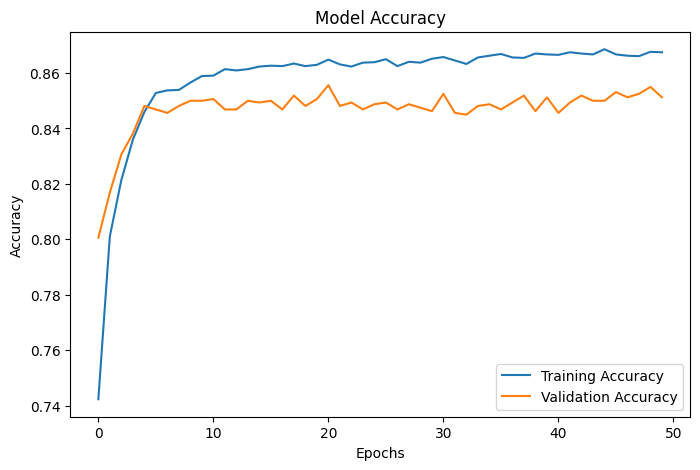

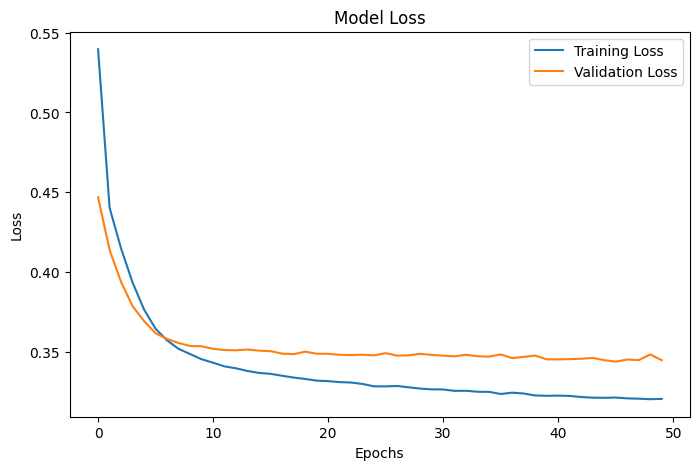

In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ==============================
# 2. LOAD DATASET
# ==============================
df = pd.read_csv("Churn_Modelling.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)

# ==============================
# 3. DROP UNNECESSARY COLUMNS
# ==============================
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# ==============================
# 4. ENCODE CATEGORICAL DATA
# ==============================
# Gender
le_gender = LabelEncoder()
df["Gender"] = le_gender.fit_transform(df["Gender"])

# Geography - one hot encoding
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

print("\nColumns after encoding:")
print(df.columns)

# ==============================
# 5. SPLIT FEATURES AND TARGET
# ==============================
X = df.drop("Exited", axis=1)
y = df["Exited"]

# ==============================
# 6. TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 7. FEATURE SCALING
# ==============================
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# ==============================
# 8. BUILD ANN MODEL
# ==============================
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(units=16, activation="relu", input_dim=X_train.shape[1]))

# Second hidden layer
model.add(Dense(units=8, activation="relu"))

# Output layer
model.add(Dense(units=1, activation="sigmoid"))

# ==============================
# 9. COMPILE MODEL
# ==============================
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# ==============================
# 10. TRAIN MODEL
# ==============================
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ==============================
# 11. PREDICTIONS
# ==============================
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# ==============================
# 12. EVALUATE MODEL
# ==============================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==============================
# 13. PLOT ACCURACY GRAPH
# ==============================
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# ==============================
# 14. PLOT LOSS GRAPH
# ==============================
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()